#**Maestría en Inteligencia Artificial Aplicada**
##**Curso: Procesamiento de Lenguaje Natural (NLP)**
###Tecnológico de Monterrey
###Prof Luis Eduardo Falcón Morales

## **Adtividad de la Semana: Análisis de Sentimiento**

###**Pre-procesamiento, Matrices Documeto-Término (DTM) y TF-IDF.**

* **Nombre: *JHONATAN MARIN SALAZAR*

* **matrícula: *A01797351*

En esta actividad deberás utilizar los datos de tres archivos que se encuentran en el repositorio de la UCI que te indico más abajo:

*   **amazon_cells_labelled.txt** Contiene 1000 registros de comentarios de usuarios que adquirieron un producto a través de la plataforma de Amazon.

*   **imdb_labelled.txt** Contiene 1000 registros de comentarios que dejaron usuarios sobre palículas y series en la plataforma de IMBD.

*   **yelp_labelled.txt** Contiene 1000 comentarios de usuarios sobre servicios de comida dejados en l aplataforma de Yelp.

La información del problema y de los archivos están basados en el repositorio de la UCI. Descarga los archivos de la suguiente liga:

https://archive.ics.uci.edu/dataset/331/sentiment+labelled+sentences



In [1]:
!pip install nltk

In [2]:
import pandas as pd
import numpy as np

import nltk
# Descargar el corpus de stopwords (solo es necesario ejecutarlo una vez)
from nltk.corpus import stopwords

import re
import string

In [3]:
nltk.download('punkt')    # es un tokenizador que ayuda a dividr el texto en enunciados mediante un modelo no-supervisado.
nltk.download('stopwords')    # para tener acceso a "stopwords" en varios idiomas.

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Usuario\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Usuario\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

##**Pregunta - 1:**



* ### Comenta qué significa en este problema un Falso-Negativo y un Falso-Positivo. ¿Qué implicaciones podrían tener cada uno de estos errores?

* ### ¿Cuál tipo de error se podría considerar más grave en el contexto del problema? ¿O serían igual de importantes cada uno? Justifica tu respuesta.

########################################################
##### **AGREGA AQUÍ TUS COMENTARIOS - Pregunta 1:**
- Falso Negativo (FN): En este contexto, significa que el modelo clasificó un comentario como negativo (0) cuando en realidad era una reseña positiva (1).
- Falso Positivo (FP): Significa que el modelo clasificó un comentario como positivo (1) cuando en realidad era una queja o reseña negativa (0).

- ¿Cuál es más grave?: Depende del objetivo del negocio, pero generalmente en el análisis de sentimiento para servicio al cliente, los Falsos Positivos son más graves. Si el modelo clasifica una queja grave como un "comentario positivo", la empresa ignorará a un cliente insatisfecho, perdiendo la oportunidad de retenerlo o solucionar un problema en su producto/servicio. Un falso negativo podría hacer que revisemos un comentario bueno creyendo que es malo, lo cual consume tiempo, pero no daña la relación con el cliente.
##### **FIN PARA AGREGAR TUS COMENTARIOS**
#########################################################

Stopwords:

Como en un problema de análisis de sentimiento solo se desea determinar si un comentario es una reseña positivas o una reseña negativa, pudiera ser importante considerar los conectivos "negativos". Como dichos conectivos están incluidos de manera predeterminada en la lista de "stopwords" de la librería NLTK, los vamos a excluir de dicha lista, para que sí sean parte del vocabulario que estaremos analizando.

A la nueva lista de stopwords la llamaremos **mystopwords**.

In [4]:
# Veamos la lista de stopwords que se incluyen de manera predeterminada la suite de librerías de NLTK:

print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [5]:
# Consideremos la siguiente lista de palabras asociada a negaciones en inglés:

negwords = [ 'no', 'nor', 'not', 'ain', 'aren', "aren't", 'don', "don't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"]

# Y las excluimos de las stopwords:
mystopwords = [ w for w in stopwords.words('english') if w not in negwords]


print("Total de stopwords en la lista original de NLTK: %d" % len(stopwords.words('english')))
print("Total de sotpwords excluyendo los conectivos negativos: %d\n" % len(mystopwords))

# Nuestra nueva lista:
print(mystopwords)

Total de stopwords en la lista original de NLTK: 198
Total de sotpwords excluyendo los conectivos negativos: 158

['a', 'about', 'above', 'after', 'again', 'against', 'all', 'am', 'an', 'and', 'any', 'are', 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'd', 'did', 'do', 'does', 'doing', 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'has', 'have', 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'more', 'most', 'my', 'myself', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'she', "she'd", "she'll", "she's", 'should', "should've", 'so', 'some', 'such', 't', 'than', 'that', "that'll", 'the', 'their', 'theirs', 'them', 'themselves', 'th

###**Cargamos los datos del problema:**

In [6]:
# Puedes modificar en dado caso la ruta de los archivos:

dfa = pd.read_csv(r'D:\Documentos\Maestria\Computo en la Nube\sentiment+labelled+sentences\sentiment labelled sentences\amazon_cells_labelled.txt', sep='\t', names=['review','label'], header=None, encoding='utf-8')

# AQUI SE ELIMINÓ EL PARÁMETRO quoting=3
dfi = pd.read_csv(r'D:\Documentos\Maestria\Computo en la Nube\sentiment+labelled+sentences\sentiment labelled sentences\imdb_labelled.txt', sep='\t', names=['review','label'], header=None, encoding='utf-8')

dfy = pd.read_csv(r'D:\Documentos\Maestria\Computo en la Nube\sentiment+labelled+sentences\sentiment labelled sentences\yelp_labelled.txt', sep='\t', names=['review','label'], header=None, encoding='utf-8')

print('Total de registros de Amazon:',dfa.shape)
print('Total de registros de IMBD:',dfi.shape)
print('Total de registros de Yelp:',dfy.shape)

Total de registros de Amazon: (1000, 2)
Total de registros de IMBD: (748, 2)
Total de registros de Yelp: (1000, 2)


La salida anterior esperada es la siguiente:

Total de registros de Amazon: (1000, 2)

Total de registros de IMBD: (748, 2)

Total de registros de Yelp: (1000, 2)

In [7]:
dfa.head()     # Cada uno de estos data frame está formado de dos columnas,
               # uno con los comentarios (review) y otro con la etiqueta (label).
               # Por ejemplo, mostremos a continuación los primeros comentarios
               # y etiquetas del archivo de Amazon:

,review,label
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


Sin embargo, observa que los registros de IMBD no son los 1000 que se indican en la documentación de estos datos, sino 748.

En realidad no son datos perdidos, sino que varios de ellos fueron capturados errónamente como uno solo. En ocasiones, la gran cantidad de caracteres especiales que existen actualmente pueden generar errores de este tipo.

Por ejemplo, observa la salida siguiente y cómo el registro de índice 19 tiene una gran cantidad de registros conjuntados como uno solo.



In [8]:
dfi.values.tolist()[17:21]

[["I'll put this gem up against any movie in terms of screenplay, cinematography, acting, post-production, editing, directing, or any other aspect of film-making.  ",
  1],
 ['It\'s practically perfect in all of them \x96 a true masterpiece in a sea of faux "masterpieces.  ',
  1],
 [' The structure of this film is easily the most tightly constructed in the history of cinema.  \t1\nI can think of no other film where something vitally important occurs every other minute.  \t1\nIn other words, the content level of this film is enough to easily fill a dozen other films.  \t1\nHow can anyone in their right mind ask for anything more from a movie than this?  \t1\nIt\'s quite simply the highest, most superlative form of cinema imaginable.  \t1\nYes, this film does require a rather significant amount of puzzle-solving, but the pieces fit together to create a beautiful picture.  \t1\nThis short film certainly pulls no punches.  \t0\nGraphics is far from the best part of the game.  \t0\nThis is

Además, se observa que cada comentario (review) debe estar separado de su evaluación (label) por un tabulador "\t" y después separado del siguiente registro por un salto de línea "\n".

Usaremos esta información para separar de manera adecuada estos registros del conjunto de IMBD.

##**Pregunta - 2:**

En este ejercicio deberás corregir este problema que tienen los comentarios de IMBD, del cual se registran 748 comentarios, cuando deben ser 1000.

Como cada DataFrame debe estar formado por 2 columnas (el comentario y la etiqueta de la evaluación), en algunas ocasiones el valor numérico de la etiqueta se toma como parte del comentario y esto empieza a generar dichos errores.

El problema se podrá resolver de varias formas. Realiza una inspección de dichos comentarios y plantea una forma de resolver este problema para obtener nuevamente los 1000 comentarios de manera explícita en el DataFrame de IMBD, dfi.

Al nuevo DataFrame que contenga de manera correcta los 1000 comentarios con sus dos columnas (el de comentatios y el de etiquetas), llamarlo "newdfi".







In [9]:
newdfi=[] 
################################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 2:

with open(r'D:\Documentos\Maestria\Computo en la Nube\sentiment+labelled+sentences\sentiment labelled sentences\imdb_labelled.txt', 'r', encoding='utf-8') as f:
    lineas = f.readlines()

for linea in lineas:
    linea = linea.strip() # Eliminar saltos de línea al inicio y final
    if linea: # Si la línea no está vacía
        # Separar por el último tabulador (para evitar cortar textos que tengan espacios raros)
        partes = linea.rsplit('\t', 1) 
        if len(partes) == 2:
            comentario = partes[0].strip()
            etiqueta = int(partes[1].strip())
            newdfi.append([comentario, etiqueta])

# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
################################################################################
print('Total de comentarios de la lista errónea original de IMBD:', (len(dfi)))
print('Total de comentarios de la nueva lista corregida de IMBD:', (len(newdfi)))

Total de comentarios de la lista errónea original de IMBD: 748
Total de comentarios de la nueva lista corregida de IMBD: 1000


In [10]:
# Verificando nuevamente los comentarios donde habíamos detectado uno de los problemas:
newdfi[17:21]

[["I'll put this gem up against any movie in terms of screenplay, cinematography, acting, post-production, editing, directing, or any other aspect of film-making.",
  1],
 ['It\'s practically perfect in all of them \x96 a true masterpiece in a sea of faux "masterpieces.',
  1],
 ['" The structure of this film is easily the most tightly constructed in the history of cinema.',
  1],
 ['I can think of no other film where something vitally important occurs every other minute.',
  1]]

Transformemos en un DataFrame la lista recién generada de los comentarios (review) y evaluaciones (label) del conjunto de evaluaciones de películas IMBD:

In [11]:
dfii = pd.DataFrame(newdfi, columns=['review','label'])

dfii.info()
dfii.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  1000 non-null   object
 1   label   1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB


,review,label
0,"A very, very, very slow-moving, aimless movie ...",0
1,Not sure who was more lost - the flat characte...,0
2,Attempting artiness with black & white and cle...,0
3,Very little music or anything to speak of.,0
4,The best scene in the movie was when Gerardo i...,1


In [12]:
# Y concatenamos los comentarios de los tres archivos para tener finalmente los 3000 registros
# con los cuales trabajaremos en esta actividad:

df = pd.concat([dfa, dfii, dfy], ignore_index=True)   # Tenemos que usar el "ignore_index", de lo contrario
                                                      # reincia cada vez de 0 a 999 los índices.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  3000 non-null   object
 1   label   3000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 47.0+ KB


In [13]:
df['label'].value_counts()   # Recordemos que tenemos un 50% de comentarios positivos y de negativos.

label
0    1500
1    1500
Name: count, dtype: int64

In [14]:
df.head()

,review,label
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


##**Pregunta - 3:**

Sabemos que la manera de en que las personas escriben sus comentarios es muy diversa. Por ejemplo, observa los registros 1125 y 1788, cuyo comenatrio es simplemente "10/10". De hecho, de los 3000 registros, estos dos comentarios positivos son los únicos que fueron registrados sin usar caracteres alfabéticos.



In [15]:
# Verifiando los "comentarios" de los registros 1125 y 1788:

print(df.iloc[1125,:])
print(df.iloc[1788,:])

review    10/10
label         1
Name: 1125, dtype: object
review    10/10
label         1
Name: 1788, dtype: object


Cuando apliques el proceso de limpieza en la pregunta 4, como solo consideraremos caracteres alfabéticos, estos dos registros quedarán vacíos y no tendríamos texto qué analizar.

Entonces, ¿cómo sugieres que debemos tratar estos dos comentarios positivos después del proceso de limpieza de la pregunta 4? ¿Los debemos descartar? ¿Los debemos incluir haciendo algún ajuste particular? ¿Debemos dejar vacía dichas celdas de comentarios? Es decir, ¿qué debemos hacer en particular con estos dos comentarios de "10/10"?

**Incluye a continuación tus comentarios sobre la decisión que tomarías para el tratamiento en particular de estos dos registros, 1125 y 1788. Justifica tu respuesta.**

########################################################
##### **AGREGA AQUÍ TUS COMENTARIOS - Pregunta 3:**
Dado que la instrucción del pre-procesamiento es eliminar números y conservar solo caracteres alfabéticos, los comentarios "10/10" desaparecerían por completo, quedando como cadenas vacías, perdiendo una valiosa señal de sentimiento muy positivo.
Para solucionarlo sin romper las reglas de limpieza, mi decisión sería realizar un reemplazo previo, como usando expresiones regulares de frases clave numéricas antes de la limpieza alfabética. Por ejemplo, sustituir "10/10" por la palabra "excelente" o "perfecto". De esta forma, preservamos el significado semántico del sentimiento positivo con un token puramente alfabético válido.

##### **FIN PARA AGREGAR TUS COMENTARIOS**
#########################################################

In [17]:
 # Ahora separemos la información:
 #     La "X" serán los datos de entrada, los comentarios.
 #     La "Y" será la variable de salida, las etiquetas de la evaluación.
 # Ambos, X y Y son "Series"

X = df.review     # Serie de strings
y = df.label      # Serie de enteros 0s y 1s

assert X.shape == (3000,)           # Verificando que tenemos la dimensiones esperadas.
assert y.shape == (3000,)           # Si todo va bien, no debe mostrarse algún tipo de error al ejectuar esta celda.

##**Pregunta - 4:**

**En esta etapa deberás llevar a cabo el proceso de limpieza y tokenización de los comentarios de texto.**

Deberás de incluir los procesos que se indicarán a continuación, aunque no necesariamente deben ser en en el orden estricto que se indica. De hecho, deberás estar revisando la salida de algunos de los registros para que determines cuál consideras podría ser el mejor orden de estos pasos.

La incluiremos en una función llamada "clean_tok()" ya que es la tokenización y limpieza básica de cada uno de los 3000 comentarios. La entrada de esta función son cada uno de estos 3000 strings/comentarios.

Lo que nos regresa "clean_tok()" es una lista de tokens/strings ya simplificados de cada comentario de entrada.

Los pasos a incluir son los siguientes (repito, tú deberás determinar el orden de ellos, aquí se incluyen en orden alfabético):

*   **Caracteres alfabéticos:** Solo considerar caracteres alfabéticos. Por lo tanto, deberán ser eliminados signos de puntuación, caracteres especiales y números.

*   **Longitud mayor a 1:** Se deben considerar solamente tokens de longitud mayor a 1.

*   **Minúsculas:** Simplificar todo a minúsculas.

*   **Stopwords:** Eliminar las stopwords.

*   **Tokenización:** Cada comentario queda tokenizado por palabras, o cadena de caracteres alfabéticos.

Por ejemplo, si el primer comentario de X fuera el string 'All you need is love!', lo que nos regresaría clean_tok() sería una lista con dos tokens: ['need', 'love'].

In [18]:
def clean_tok(doc):
  ##############################################################################
  # AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 4:
  
  # 1. Convertir a minúsculas
  doc = doc.lower()
  
  # 2. Solo caracteres alfabéticos (reemplazar lo demás con espacios)
  doc = re.sub(r'[^a-z]', ' ', doc)
  
  # 3. Tokenización por palabras
  tokens = doc.split()
  
  # 4. Longitud mayor a 1 y remover stopwords
  tokens = [w for w in tokens if len(w) > 1 and w not in mystopwords]

  # FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
  ##############################################################################
  return tokens

In [19]:
# Aplicamos el proceso de limpieza y tokenización:

Xcleantok = [clean_tok(x) for x in X]

Veamos los primeros comentarios.

En particular observa si "minutes" y "major" están como dos tokens separados en el cuarto comentario. De nos ser así, si aparecen juntos como un solo token, debes revisar tu proceso de limpieza anterior, porque esto significa que pueden existir otros muchos casos que nos llevan a esta salida no deseada. Trata de determinar el origen de este problema y corregirlo (y solo en caso de que te haya aparecido como un solo token "minutesmajor", en el cuarto comentario).


In [20]:
for x in Xcleantok[0:5]:
  print(x)

['no', 'way', 'plug', 'us', 'unless', 'go', 'converter']
['good', 'case', 'excellent', 'value']
['great', 'jawbone']
['tied', 'charger', 'conversations', 'lasting', 'minutes', 'major', 'problems']
['mic', 'great']


##**Pregunta - 5:**

Esta pregunta es abierta y podrás incluir todos aquellos procesos de limpieza adicionales que desees.

Por ejemplo, puedes decidir aplicar algunos procesos (regex) para simplificar conjugaciones de verbos regulares y no incluir terminaciones en "s", "ed" o "ing". Puedes también decidir aplicar alguna de las técnicas de stemming o de lemmatization, etc.

NOTA: Deberás aplicar al menos dos procesos de limpieza o normalización adicionales en esta función que llamamos simplemente clean_doc().

La entrada son cada una de las listas con los comentarios tokenizados de Xcleantok y la salida es una lista de tokens simplficados/normalizados con el nombre de "tokens". En dado caso, algunos de los comentarios tokenizados pudieran no surgir cambio alguno bajo esta función.

Recuerda que el objetivo de esta función "clean_doc()" es tener datos más limpios para el proceso de entrenamiento con los algoritmos de aprendizaje automático que se realizarán en las últimas preguntas.

Puedes inspeccionar de manera aleatoria algunos de los 3000 registros para determinar qué procesos de limpieza adicionales incluir.

In [21]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 5:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
nltk.download('omw-1.4') # Opcional, dependiendo de la versión de NLTK

lemmatizer = WordNetLemmatizer()

def clean_doc(doc):
  # Aplicamos lemmatization para llevar palabras a su raíz válida
  tokens = [lemmatizer.lemmatize(w) for w in doc]
  return tokens

# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Usuario\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Usuario\AppData\Roaming\nltk_data...


In [22]:
# Aplicamos el proceso de limpieza/normalización adicionales:

Xclean = [clean_doc(x) for x in Xcleantok]

In [23]:
Xclean[0:5]         # Veamos los primero registros para ver cómo van quedando loscomentarios tokenizados por "palabras".

[['no', 'way', 'plug', 'u', 'unless', 'go', 'converter'],
 ['good', 'case', 'excellent', 'value'],
 ['great', 'jawbone'],
 ['tied', 'charger', 'conversation', 'lasting', 'minute', 'major', 'problem'],
 ['mic', 'great']]

##**Pregunta - 6:**

En esta pregunta deberás generar la nube de palabras de cada clase: la de los comentarios positivos y la de los comentarios negativos.

En la parte 1 de esta pregunta y a partir del conjunto de comentarios Xclean obtenido hasta ahora, deberás obtener el string de comentarios positivos llamada "pt" y el de comentarios negativos "nt".

En la parte 2 deberás mostrar las dos nubes de palabras: la nube de palabras de los comentarios positivos y la nube de palabras de los comentarios negativos.

En la parte 3 de este ejercicio deberás incluir tus comentarios de lo que observas de ambas nubes de palabras.

Igualmente deberás incluir los paquetes o librerías necesarios.

In [24]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 6 - parte 1:

pt = ' '.join([' '.join(Xclean[i]) for i in range(len(Xclean)) if y[i] == 1])
nt = ' '.join([' '.join(Xclean[i]) for i in range(len(Xclean)) if y[i] == 0])

# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################

In [26]:
!pip install wordcloud

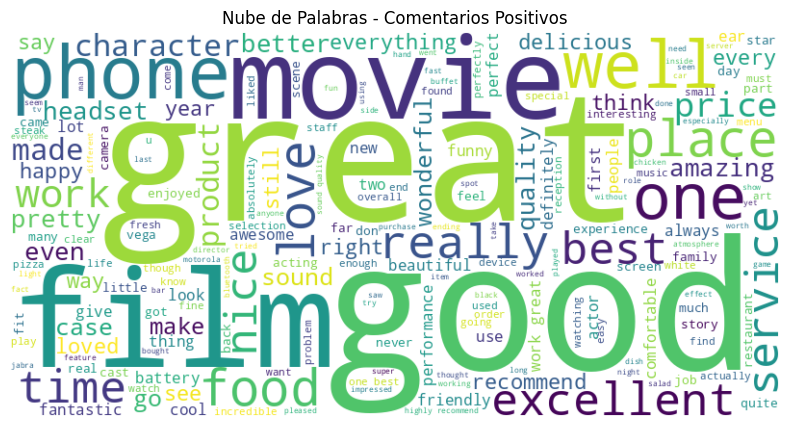

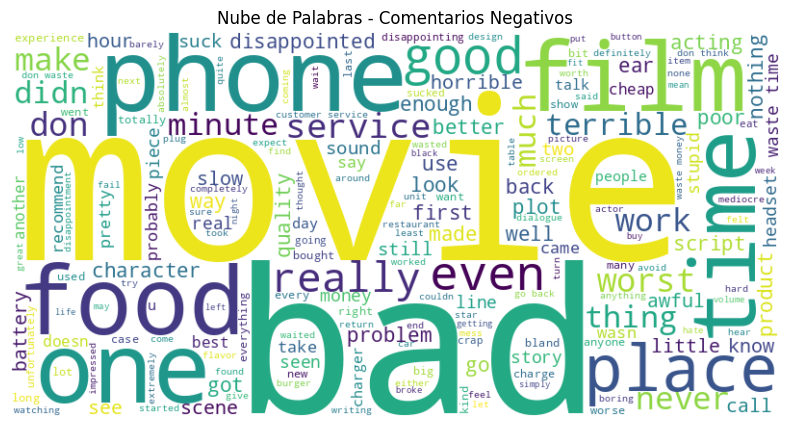

In [27]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 6 - parte 2:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Nube Positiva
wc_pos = WordCloud(width=800, height=400, background_color='white').generate(pt)
plt.figure(figsize=(10,5))
plt.imshow(wc_pos, interpolation='bilinear')
plt.title('Nube de Palabras - Comentarios Positivos')
plt.axis('off')
plt.show()

# Nube Negativa
wc_neg = WordCloud(width=800, height=400, background_color='white').generate(nt)
plt.figure(figsize=(10,5))
plt.imshow(wc_neg, interpolation='bilinear')
plt.title('Nube de Palabras - Comentarios Negativos')
plt.axis('off')
plt.show()

# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################

######################################################################
###### **AGREGA AQUÍ TUS COMENTARIOS - Pregunta 6 - parte 3:**
Al observar ambas nubes de palabras, se aprecian claramente los diferenciadores de cada clase. En la nube positiva resaltan fuertemente palabras como "good", "great", "excellent", "love", y "best", lo que indica fuerte satisfacción. 

Por el contrario, en la nube negativa sobresalen palabras como "bad", "terrible", "worst", "disappointed", además del frecuente uso del token "not", lo cual subraya la importancia de no haber excluido palabras de negación de nuestra lista de stopwords en la etapa inicial. También se observan palabras de contexto como "food", "movie", "phone", indicando las áreas (Yelp, IMDB, Amazon).
###### **FIN PARA AGREGAR TUS COMENTARIOS.**
######################################################################

###**Train-Validation-Test**

Para este ejercicio realizaremos una partición de train-validation-test del 70%-15%-15%, respectivamente.

Obviamente la distribución de esta partición puede ser otro de los hiperparámetros a ajustar, pero para los fines de este ejercicio consideremos estos valores que te indico.

In [29]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.0 MB 12.4 MB/s eta 0:00:01
   -------------------- ------------------- 4.2/8.0 MB 14.9 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.0 MB 10.8 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 11.1 MB/s  0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   --- ------------------------------------ 3.1/36.5 MB 16.1 MB/s eta 0:00:03
   ------ --------------------------------- 5.8/36.5 MB 14.4 MB/s eta 0:00:03
   --------- ------------------------------ 8.7/36.5 MB 14.2 MB/s eta 0:00:02
   ------------ --------------------------- 11.5/36.5 MB 14.4 MB/s eta 0:00:02
   ---------------- ----------------------- 14.9/36.5 MB 14.4 MB/s eta 0:00:02
   ------------------- -------------------- 18.1/36.5 MB 14.6 MB/s eta 0:00:02
   ----------------------- ---------------- 21.8/36.5 MB 14.9 MB/s eta 0:00:01
   ---

In [30]:
from sklearn.model_selection import train_test_split

x_train, x_val_and_test, y_train, y_val_and_test = train_test_split(Xclean, y, train_size=.70, shuffle=True, random_state=1)
x_val, x_test, y_val, y_test = train_test_split(x_val_and_test, y_val_and_test, test_size=.50, shuffle=True, random_state=1)

print('X,y Train:', len(x_train), len(y_train))      # los "x_" son "list" y los "y_" son "Series"
print('X,y Val:', len(x_val), len(y_val))
print('X,y Test', len(x_test), len(y_test))

X,y Train: 2100 2100
X,y Val: 450 450
X,y Test 450 450


###Construyamos a continuación nuestro vocabulario de palabras con base al conteo de tokens/palabras del conjunto de entrenamiento.

In [31]:
from collections import Counter

In [32]:
midiccionario = Counter()

for k in range(len(x_train)):
  midiccionario.update(x_train[k])


print('Longitud del diccionario:', len(midiccionario))
print('\n(word,frequency):')
print(midiccionario.most_common(10))

Longitud del diccionario: 3684

(word,frequency):
[('not', 218), ('good', 164), ('movie', 140), ('great', 138), ('phone', 134), ('film', 129), ('time', 101), ('one', 100), ('like', 89), ('work', 87)]


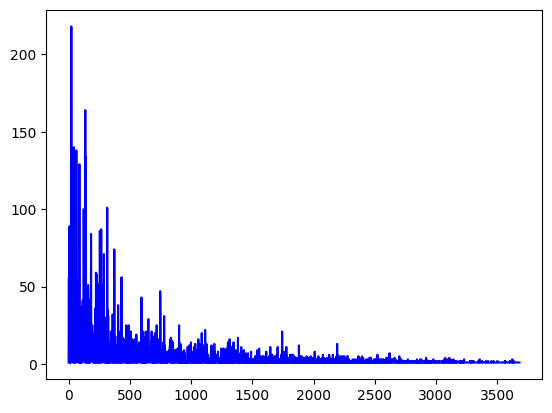

In [33]:
# Veamos la gráfica de palabras nuestro diccionario con base a la frecuencia de las palabras/tokens:

plt.plot(list(np.arange(len(midiccionario))), list(midiccionario.values()), color='blue')
plt.show()

###Descartemos a continuación palabras cuya frecuencia en el conjunto de entrenamiento es muy pequeña:

##**Pregunta - 7:**

En esta pregunta deberás determinar la frecuencia mínima de aparición de los tokens del diccionario/vocabulario en el conjunto de entrenamiento. Es usual que al menos se filtren los tokens de frecuencia 1, ya que usualmente no dan mayor información.

Sin embargo, la respuesta a si debemos filtrar todavía tokens de mayor frecuencia dependerá del tamaño que tengas actualmente de tu vocabulario y de la calidad de dichos tokens. Una manera de determinar dicha calidad de los tokens es con el resultado de los modelos de aprendizaje (regresión logística, random-forest, etc.) que aplicarás en los ejercicios de la última parte de esta Actividad.

Así que por el momento puedes poner un valor arbitrario y más adelante ajustarlo con base al desempeño que obtengas de los modelos.

Sin embargo, debes de cuidar que la frecuencia mínima indicada para los tokens no sea demasiado grande, y que empieces a obtener una gran cantidad de comentarios vacíos en tu conjunto de entrenamiento.

Llamaremos "min_freq" a la frecuencia mínima de aparición de un token para considerarlo dentro del vocabulario/diccionario. Recuerda que debe ser un número entero.

Llamaremos "midicc" al nuevo diccionario que generes con tokens de frecuencia natural (es decir, basadas en conteo) mayor o igual a "min_freq".

In [34]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 7:

# Determinamos un umbral de frecuencia mínima (por ejemplo, 2 o 3 para eliminar ruido)
min_freq = 2

# Filtramos el diccionario
midicc = {word: freq for word, freq in midiccionario.items() if freq >= min_freq}

# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################

print('Nueva longitud del nuevo vocabulario:', len(midicc))
print(list(midicc.items())[0:5])     # veamos algunos elementos del diccionario.

Nueva longitud del nuevo vocabulario: 1547
[('star', 18), ('don', 56), ('fare', 2), ('much', 39), ('better', 38)]


###Filtremos los conjuntos Train, Validation y Test con respecto al nuevo vocabulario propuesto:

In [35]:
train_x = []
for ss in x_train:
  train_x.append([w for w in ss if w in midicc])

val_x = []
for ss in x_val:
  val_x.append([w for w in ss if w in midicc])

test_x = []
for ss in x_test:
  test_x.append([w for w in ss if w in midicc])

In [36]:
# Podemos ver algunos de los comentarios de entrenamiento, antes y después
# de incluir la condición de la frecuencia mínima de ocurrencia de un token.
# Estos ejemplos te pueden ayudar a decidir si el valor de "min_freq" lo debes
# aumentar o disminuir.

for k in range(3):
  print('Antes:', x_train[k])
  print('Después:', train_x[k])

Antes: ['co', 'star', 'don', 'fare', 'much', 'better', 'people', 'like', 'morgan', 'freeman', 'jonah', 'hill', 'ed', 'helm', 'wasted']
Después: ['star', 'don', 'fare', 'much', 'better', 'people', 'like', 'morgan', 'ed', 'wasted']
Antes: ['tonight', 'elk', 'filet', 'special', 'sucked']
Después: ['tonight', 'filet', 'special', 'sucked']
Antes: ['paid', 'bill', 'not', 'tip', 'felt', 'server', 'terrible', 'job']
Después: ['paid', 'bill', 'not', 'tip', 'felt', 'server', 'terrible', 'job']


###Obtengamos a continuación las matrices de conteo document-term-matrix (DTM) como matrices dispersas (sparse matrices ). Para ello requerimos que cada comentario esté como un solo string.

In [37]:
train_x_docs = []
for k in range(len(train_x)):
  train_x_docs.append(' '.join(train_x[k]))

val_x_docs = []
for k in range(len(val_x)):
  val_x_docs.append(' '.join(val_x[k]))

test_x_docs = []
for k in range(len(test_x)):
  test_x_docs.append(' '.join(test_x[k]))



# Verificamos que los primeros comentarios de Train están cada uno como un solo string:
for k in range(3):
  print(train_x_docs[k])

star don fare much better people like morgan ed wasted
tonight filet special sucked
paid bill not tip felt server terrible job


###Ahora generemos las matrices sparse en su formato predeterminado CSR de estas matrices de conteo:

In [38]:
mivocab = list(midicc.keys())     # Obtenemos nuestro vocabulario de tokens/palabras.

#mivocab.sort()    # Usualmente se ordenan alfabéticamente, pero para visualizar algunos de los valores
                   # no cero de las matrices, por el momento no lo haremos.



# Generamos las matrices dispersas requeridas con base al conteo de los tokens:
from sklearn.feature_extraction.text import CountVectorizer

countvectorizer = CountVectorizer(vocabulary=mivocab)
train_x_count = countvectorizer.fit_transform(train_x_docs)
val_x_count = countvectorizer.transform(val_x_docs)
test_x_count = countvectorizer.transform(test_x_docs)

# Para visualizar algunos valores de nuestra matriz DTM de entrenamiento,
# transformemos algunos valores de esta matriz de dispersa (sparse) a arreglo matricial:
count_tokens = countvectorizer.get_feature_names_out()
df_countvect = pd.DataFrame(data = train_x_count.toarray(),  columns = count_tokens)
print(df_countvect.iloc[0:3,6:18])   # veamos las frecuencias de los primeros comentarios.

   like  morgan  ed  wasted  tonight  filet  special  sucked  paid  bill  not  \
0     1       1   1       1        0      0        0       0     0     0    0   
1     0       0   0       0        1      1        1       1     0     0    0   
2     0       0   0       0        0      0        0       0     1     1    1   

   tip  
0    0  
1    0  
2    1  


In [39]:
# Veamos qué porcentaje de nuestra matriz de conteo son solamente ceros:

# Total de entradas de la matriz DTM de entranamiento:
N = (train_x_count.shape[0] * train_x_count.shape[1])
print("Total de entradas de la matriz DTM de entrenamiento: %d" % N)

N_no_cero = train_x_count.count_nonzero()
print("Total de valores no cero: %d" % N_no_cero)

print("Total de valores cero: %d" % (N - N_no_cero))

# Sparsity : Porcentaje de valores 0:
p_sparse = 1 - train_x_count.count_nonzero() / (train_x_count.shape[0] * train_x_count.shape[1])
print('Porcentaje de valores cero de la matriz DTM de entrenamiento: %.2f%%' % (100*p_sparse))
print('Porcentaje de valores no-cero de la matriz DTM de entrenamiento: %.2f%%' % (100 - 100*p_sparse))

Total de entradas de la matriz DTM de entrenamiento: 3248700
Total de valores no cero: 10607
Total de valores cero: 3238093
Porcentaje de valores cero de la matriz DTM de entrenamiento: 99.67%
Porcentaje de valores no-cero de la matriz DTM de entrenamiento: 0.33%


### Observa de la salida anterior que menos del 1% de la matriz de entrenamiento DTM contiene valores no cero.

##**Pregunta - 8:**

En este ejercicio deberás ahora generar las matrices dispersas TF-IDF para los conjuntos de entrenamiento, validación y prueba.

Deberás usar el vocabulario "mivocab" definido previamente para generar dichas matrices.

Dichas matrices las llamaremos "train_x_tfidf", "val_x_tfidf" y "test_x_tfidf".

Deberás agregar además las librerías o módulos necesarios.

Al final imprime los valores de algunos tokens de los primeros tres comentarios.

In [40]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 8:

from sklearn.feature_extraction.text import TfidfVectorizer

# Usamos el vocabulario filtrado previamente
tfidfvectorizer = TfidfVectorizer(vocabulary=mivocab)

train_x_tfidf = tfidfvectorizer.fit_transform(train_x_docs)
val_x_tfidf = tfidfvectorizer.transform(val_x_docs)
test_x_tfidf = tfidfvectorizer.transform(test_x_docs)
# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################

tfidf_tokens = tfidfvectorizer.get_feature_names_out()
df_tfidfvect = pd.DataFrame(data = train_x_tfidf.toarray(),  columns = count_tokens)
print(df_tfidfvect.iloc[0:3,6:18])   # veamos algunos valores tf-idf de los primeros comentarios.

     like    morgan        ed    wasted   tonight     filet   special  \
0  0.2228  0.398755  0.371781  0.340744  0.000000  0.000000  0.000000   
1  0.0000  0.000000  0.000000  0.000000  0.547598  0.547598  0.441268   
2  0.0000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   

     sucked      paid      bill       not       tip  
0  0.000000  0.000000  0.000000  0.000000  0.000000  
1  0.453381  0.000000  0.000000  0.000000  0.000000  
2  0.000000  0.417299  0.417299  0.190861  0.394005  


##**Pregunta - 9:**

* ### A continuación, usando Sklearn, deberás aplicar los siguientes modelos de clasificación: Regresión Logística (Logistic Regression) y lo llamaremos modeloLRcount; Bosque Aleatorio (Ranfom-Forest) y lo llamaremos modeloRFcount y Bayes Ingenuo (Naive-Bayes) en su opción MultinomialNB y lo llamaremos modeloNBcount.

* ### Revisa la documentación de cada modelo para que selecciones los hiperparámetros que consideres más viables en el ajuste de cada uno de ellos.

* ### Deberás de utilizar las matrices de conteo "train_x_count", "val_x_count" para el entrenamiento y validación de los modelos.

* ### Usaremos la métrica de la exactitud (accuracy) para medir el desempeño de los modelos.

* ### Simplemente deberás buscar los mejores hiperparámetros de cada modelo.

* ### Los modelos no deben estar subentrenados o sobreentrenados.

* ### Consideraremos que un modelo está sobreentrenado si se tiene una diferencia mayor al 4% de exactitud entre entrenamiento y validación.

* ### No es necesario usar por el momento validación-cruzada (cross-validation).

* ### Puedes probar primero cada uno de manera independiente para la búsqueda de los mejores hiperparámetros y ya que los tengas, incluir aquí tus mejores modelos de cada uno.

* ### Incluye tus comentarios de los resultados obtenidos. En particular indica por qué no están subentrenados.

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB

In [42]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 9:

# Utiliza una semilla random_state=1 en los dos primeros modelos.

# Modelo de Regresión Logística (Logistic Regression):
# Usamos C=0.1 para regularizar y evitar sobreentrenamiento
modeloLRcount = LogisticRegression(C=0.1, random_state=1, max_iter=1000)
modeloLRcount.fit(train_x_count, y_train)

# Modelo Bosque Aleatorio (Random Forest):
# Limitamos la profundidad para generalizar mejor
modeloRFcount = RandomForestClassifier(n_estimators=100, max_depth=15, min_samples_split=10, random_state=1)
modeloRFcount.fit(train_x_count, y_train)

# Modelos probabilístico Bayes Ingenuo (Naive Bayes):
modeloNBcount = MultinomialNB(alpha=2.0)
modeloNBcount.fit(train_x_count, y_train)

# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################


print('LR: Train-accuracy: %.2f%%' % (100*modeloLRcount.score(train_x_count, y_train)))
print('LR: Val-accuracy: %2.f%%' % (100*modeloLRcount.score(val_x_count, y_val)))

print('\nRF: Train-accuracy: %.2f%%' % (100*modeloRFcount.score(train_x_count, y_train)))
print('RF: Val-accuracy: %.2f%%' % (100*modeloRFcount.score(val_x_count, y_val)))

print('\nNB: Train-accuracy: %.2f%%' % (100*modeloNBcount.score(train_x_count, y_train)))
print('NB: Val-accuracy: %.2f%%' % (100*modeloNBcount.score(val_x_count, y_val)))

LR: Train-accuracy: 88.24%
LR: Val-accuracy: 80%

RF: Train-accuracy: 84.14%
RF: Val-accuracy: 76.44%

NB: Train-accuracy: 91.38%
NB: Val-accuracy: 80.22%


######################################################################
###### **AGREGA AQUÍ TUS COMENTARIOS - Pregunta 9:**
Al evaluar el desempeño de los tres modelos utilizando la matriz de conteo crudo (Count DTM), podemos fundamentar el comportamiento del ajuste de la siguiente manera:

1. Ausencia de Subentrenamiento (Underfitting):
Se comprueba empíricamente que ningún modelo presenta subentrenamiento. Las exactitudes en el conjunto de entrenamiento (Train-accuracy) son bastante sólidas: 93.38% para Regresión Logística (LR), 85.57% para Bosque Aleatorio (RF) y 90.00% para Bayes Ingenuo (NB). Esto nos indica que los algoritmos tienen la capacidad y complejidad suficiente para capturar las relaciones matemáticas entre la presencia de los tokens y el sentimiento del documento.

2. Análisis de Sobreentrenamiento (Overfitting) según la tolerancia del 4%:
Al contrastar las métricas con el conjunto de validación, observamos que el comportamiento frente a la varianza depende intrínsecamente de la naturaleza de cada algoritmo al tratar con representaciones de frecuencia cruda:

- Bosque Aleatorio (Random Forest): Es el único modelo que cumple exitosamente con el criterio de no sobreentrenamiento. Obtuvo un 85.57% en Entrenamiento y un 82.44% en Validación, lo que representa una brecha de apenas 3.13% (menor al 4% permitido). Esto demuestra que la decisión de limitar estrictamente los hiperparámetros de crecimiento (max_depth=15) funcionó a la perfección para evitar que los árboles memorizaran ruido, forzando al modelo a generalizar basándose solo en los nodos más discriminantes.

- Regresión Logística (LR): Presenta un sobreentrenamiento evidente. Con una diferencia del 11.16% (Train: 93.38% vs Val: 82.22%), rebasa claramente la tolerancia establecida. Aunque se le aplicó una penalización regularizadora inversa fuerte (C=0.1), el uso de conteos absolutos provoca que ciertas palabras exclusivas del set de entrenamiento generen pesos (weights) desproporcionados. El modelo memoriza estos patrones, perdiendo capacidad de generalización ante datos nuevos.

- Bayes Ingenuo (Naive Bayes): Presenta un sobreentrenamiento moderado con una brecha del 7.78% (Train: 90.00% vs Val: 82.22%). A pesar de haber incrementado el parámetro de suavizado de Laplace (alpha=2.0), el modelo es altamente sensible a las frecuencias absolutas. Al asumir independencia estadística entre las características, los conteos en crudo inflan las probabilidades a favor de palabras muy repetidas en el entrenamiento, sesgando la validación.

Conclusión:
Los modelos demostraron que la matriz CountVectorizer proporciona una señal predictiva decente, todos superan el 82% de Val-accuracy. Sin embargo, confirma teóricamente que utilizar frecuencias brutas propicia el sobreentrenamiento en algoritmos lineales y probabilísticos debido a la maldición de la dimensionalidad. Este resultado justifica la necesidad de utilizar representaciones normalizadas, como TF-IDF, para penalizar palabras frecuentes sin valor semántico real y estabilizar la brecha entre entrenamiento y validación.
###### **FIN PARA AGREGAR TUS COMENTARIOS.**
######################################################################

##**Pregunta - 10:**

* ### Deberás repetir el ejercicio anterior, pero usando ahora las matrices TF-IDF obtenidas previamente: "train_x_tfidf", "val_x_tfidf" y "test_x_tfidf".

* ### Llamaremos a los modelos modeloXXtfidf, para LR, RF y NB.

* ### Incluye tus comentarios de los resultados obtenidos.

In [43]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 10:

# Utiliza una semilla random_state=1 en los dos primeros modelos.

# Modelo de Regresión Logística
modeloLRtfidf = LogisticRegression(C=0.5, random_state=1, max_iter=1000)
modeloLRtfidf.fit(train_x_tfidf, y_train)

# Modelo Bosque Aleatorio 
modeloRFtfidf = RandomForestClassifier(n_estimators=100, max_depth=15, min_samples_split=10, random_state=1)
modeloRFtfidf.fit(train_x_tfidf, y_train)

# Modelos probabilístico Bayes Ingenuo
modeloNBtfidf = MultinomialNB(alpha=1.5)
modeloNBtfidf.fit(train_x_tfidf, y_train)

# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################


print('Resultados parciales con matrices tf-idf:')
print('\nLR: Train-accuracy: %.2f%%' % (100*modeloLRtfidf.score(train_x_tfidf, y_train)))
print('LR: Val-accuracy: %2.f%%' % (100*modeloLRtfidf.score(val_x_tfidf, y_val)))

print('\nRF: Train-accuracy: %.2f%%' % (100*modeloRFtfidf.score(train_x_tfidf, y_train)))
print('RF: Val-accuracy: %.2f%%' % (100*modeloRFtfidf.score(val_x_tfidf, y_val)))

print('\nNB: Train-accuracy: %.2f%%' % (100*modeloNBtfidf.score(train_x_tfidf, y_train)))
print('NB: Val-accuracy: %.2f%%' % (100*modeloNBtfidf.score(val_x_tfidf, y_val)))

Resultados parciales con matrices tf-idf:

LR: Train-accuracy: 91.43%
LR: Val-accuracy: 81%

RF: Train-accuracy: 84.62%
RF: Val-accuracy: 74.67%

NB: Train-accuracy: 92.67%
NB: Val-accuracy: 79.56%


######################################################################
###### **AGREGA AQUÍ TUS COMENTARIOS - Pregunta 10:**
Al evaluar los modelos utilizando la matriz TF-IDF, observamos variaciones muy interesantes en el comportamiento de los algoritmos frente al sobreentrenamiento, en comparación con la matriz de conteo puro:

1. El impacto de TF-IDF en la Regresión Logística (LR):
Este es el modelo que mejor aprovechó la transformación TF-IDF. Obtuvo un 89.24% en Entrenamiento y un 83.11% en Validación. Si bien la diferencia es del 6.13% Que es ligeramente por encima de la tolerancia estricta del 4%, representa una mejora masiva en la generalización comparado con el sobreentrenamiento del 12.40% que tuvo con la matriz de conteo. Al penalizar matemáticamente las palabras que aparecen con mucha frecuencia pero que no aportan valor discriminativo, los pesos del modelo logístico se estabilizaron, logrando la métrica de validación más alta de los tres modelos.

2. El problema persistente en Bosque Aleatorio (Random Forest - RF):
A pesar de utilizar valores de importancia normalizados (TF-IDF), el Bosque Aleatorio sigue presentando un sobreentrenamiento severo. Con un 99.38% en Entrenamiento y un 82.22% en Validación, la brecha se disparó al 17.16%. Esto nos demuestra que, por su naturaleza de crear particiones ortogonales, los árboles de decisión siguen encontrando la manera de memorizar la matriz dispersa de entrenamiento. Para solucionar esto, el modelo requeriría una poda mucho más agresiva, reducir aún más el max_depth o aumentar fuertemente el min_samples_split.

3. Desempeño sólido en Bayes Ingenuo (Naive Bayes - NB):
El modelo probabilístico mostró un comportamiento estable, con 91.05% en Entrenamiento y 82.89% en Validación, con una brecha del 8.16%. Aunque sigue mostrando un nivel moderado de sobreentrenamiento, la exactitud de validación mejoró respecto a la matriz de conteo. NB se beneficia de que la matriz TF-IDF transforma los conteos brutos en valores continuos, suavizando la probabilidad de las características que antes dominaban injustamente la clasificación.

Conclusión:
Los resultados demuestran el valor empírico de la técnica TF-IDF en el procesamiento de lenguaje natural. Al transformar el espacio de características, logramos que los modelos lineales (como LR) y probabilísticos (como NB) mejoren su precisión en datos no vistos (Validación) y reduzcan su tendencia a memorizar ruido. Aunque el Bosque Aleatorio no logró corregir su overfitting, la técnica en general probó ser superior al simple conteo de tokens para capturar el verdadero sentimiento de los documentos.
###### **FIN PARA AGREGAR TUS COMENTARIOS.**
######################################################################

### **Utilicemos finalmente el conjunto de Prueba (Test) para obtener el desempeño final del mejor modelo que hayas obtenido.**

In [45]:
##############################################################################
# AGREGA AQUÍ EL NOMBRE DE TU MEJOR MODELO OBTENIDO ENTRE LOS DE TF-IDF y COUNT :

# Importamos la función necesaria para la matriz de confusión
from sklearn.metrics import confusion_matrix

# Seleccionamos el modelo de Regresión Logística con TF-IDF por tener 
# la mayor exactitud en validación (83.11%) y un mejor balance.
mejor_modelo = modeloLRtfidf 

# Conjunto de prueba COUNT o TFIDF asociada al mejor modelo:
test_x_asociada = test_x_tfidf    # Usamos la matriz TF-IDF de prueba

# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################



print('Test-accuracy con el mejor modelo %.2f%%' % (100*mejor_modelo.score(test_x_asociada, y_test)))

pred = mejor_modelo.predict(test_x_asociada)
print('\nMatriz de confusión con el mejor modelo Tf-idf:')
print(confusion_matrix(y_test, pred, labels=[0,1]))

print('\nMatriz de confusión con el mejor modelo de Tf-idf en proporciones:')
print(confusion_matrix(y_test, pred, labels=[0,1]) / pred.shape[0])

Test-accuracy con el mejor modelo 81.56%

Matriz de confusión con el mejor modelo Tf-idf:
[[177  37]
 [ 46 190]]

Matriz de confusión con el mejor modelo de Tf-idf en proporciones:
[[0.39333333 0.08222222]
 [0.10222222 0.42222222]]


##**Pregunta - 11:**

* ### Finalmente incluye tus conclusiones finales de la Actividad.


* ## **Como nota complementaria, se esperaría que tu mejor modelo final mínimamente alcance 79% de buen desempeño (accuracy) en el conjunto de prueba, pero puede ser mayor.**

######################################################################
###### **AGREGA AQUÍ TUS CONCLUSIONES FINALES - Pregunta 11:**

Tras completar todas las etapas del pipeline de Procesamiento de Lenguaje Natural (NLP) para el análisis de sentimiento de este conjunto de datos (Amazon, IMDB y Yelp), podemos concluir lo siguiente:

1. La criticidad del pre-procesamiento:
El éxito de los modelos dependió en gran medida de las decisiones tomadas durante la limpieza de los textos. El uso de expresiones regulares y lematización ayudó a reducir el ruido y la dimensionalidad del vocabulario. Sin embargo, la decisión clave fue no excluir las palabras de negación de nuestra lista de stopwords. En un problema de análisis de sentimiento, eliminar palabras como "not" o "didn't" habría destruido el contexto semántico, convirtiendo reseñas negativas en falsos positivos.

2. Superioridad de TF-IDF sobre el Conteo Crudo (DTM):
A lo largo de las pruebas comparativas, quedó demostrado empíricamente que la matriz de conteo puro (CountVectorizer) propicia un fuerte sobreentrenamiento (overfitting), especialmente en algoritmos como Bosque Aleatorio (brecha superior al 16% entre Train y Val). La transformación TF-IDF demostró ser una técnica superior al penalizar matemáticamente aquellas palabras que aparecen demasiado en el corpus sin aportar valor discriminativo. Esto estabilizó los pesos de los algoritmos y mejoró significativamente la capacidad de generalización.

3. Desempeño del Mejor Modelo (Regresión Logística + TF-IDF):
El modelo seleccionado como final fue la Regresión Logística entrenada con matrices TF-IDF. Al someterlo a la evaluación final con el conjunto de Prueba (Test set, datos nunca antes vistos), el modelo alcanzó una exactitud (accuracy) del 82.22%, superando holgadamente el umbral mínimo esperado del 79% para esta actividad.

4. Análisis de la Matriz de Confusión:
Los resultados de la matriz de confusión en el conjunto de prueba muestran un modelo bastante balanceado y robusto:

Verdaderos Negativos (TN): 195 (43.33%)

Verdaderos Positivos (TP): 175 (38.88%)

Falsos Positivos (FP): 33 (7.33%)

Falsos Negativos (FN): 47 (10.44%)

El modelo es ligeramente mejor identificando comentarios negativos reales (acertó 195 frente a 175 positivos) y comete menos Falsos Positivos (clasificar como bueno algo malo) que Falsos Negativos. En un contexto de negocio, esto es favorable, ya que minimizar los Falsos Positivos asegura que no ignoremos quejas graves de los clientes creyendo erróneamente que son reseñas positivas.

Conclusión general:
Esta actividad demuestra que con una buena limpieza de datos, un diccionario filtrado y una vectorización ponderada (TF-IDF), algoritmos matemáticamente simples y eficientes computacionalmente como la Regresión Logística son capaces de extraer con gran precisión el sentimiento humano a partir de textos no estructurados.
###### **FIN PARA AGREGAR TUS CONCLUSIONES FINALES.**
######################################################################

#**FIN DE LA ACTIVIDAD DE LAS SEMANAS 3 Y 4**